# Assignment 2 – Data Visualization

This notebook shows three example plots of the HRRR NE weather dataset:

1. A geographic **map of the region** covered by the data  
2. A spatial plot of **temperature over the 450 × 449 grid** at one time step  
3. A time-series of the **average temperature over one year** at the Jumbo Statue location

In [1]:
!pip install numpy pandas torch matplotlib cartopy

You should consider upgrading via the '/cluster/home/diavor01/SkyOracle/venv/bin/python3 -m pip install --upgrade pip' command.


In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

DATASET_DIR = '/cluster/tufts/c26sp1cs0137/data/assignment2_data/dataset'

# Jumbo Statue at Tufts
JUMBO_LAT = 42.40777867717294
JUMBO_LON = -71.12041637590173

# Reconstruct the Lambert Conformal projection used for the HRRR NE grid
projection = ccrs.LambertConformal(
    central_longitude=262.5,
    central_latitude=38.5,
    standard_parallels=(38.5, 38.5),
    globe=ccrs.Globe(semimajor_axis=6371229, semiminor_axis=6371229),
)

In [3]:
# ── Load metadata from dataset/metadata.pt ───────────────────────────────────
meta = torch.load(f'{DATASET_DIR}/metadata.pt', weights_only=False)

# Grid coordinates in the Lambert Conformal projection (metres)
x_coords = meta['grid_x']   # shape (449,)
y_coords = meta['grid_y']   # shape (450,)

# Jumbo Statue grid indices (pre-computed in metadata)
iy = meta['jumbo_y_idx']    # 177
ix = meta['jumbo_x_idx']    # 263

# Variable name → input tensor channel index
var_names   = list(meta['variable_names'])
TMP_CHANNEL = var_names.index('TMP@2m_above_ground')

print(f'Grid size   : {len(y_coords)} × {len(x_coords)}')
print(f'Jumbo point : y_idx={iy}, x_idx={ix}')
print(f'TMP channel : {TMP_CHANNEL}  ({var_names[TMP_CHANNEL]})')

Grid size   : 450 × 449
Jumbo point : y_idx=177, x_idx=263
TMP channel : 0  (TMP@2m_above_ground)


In [8]:
targets = torch.load(f'{DATASET_DIR}/targets.pt', weights_only=False)
print(len(targets["values"]))


26280


## Plot 1 – Map of the region

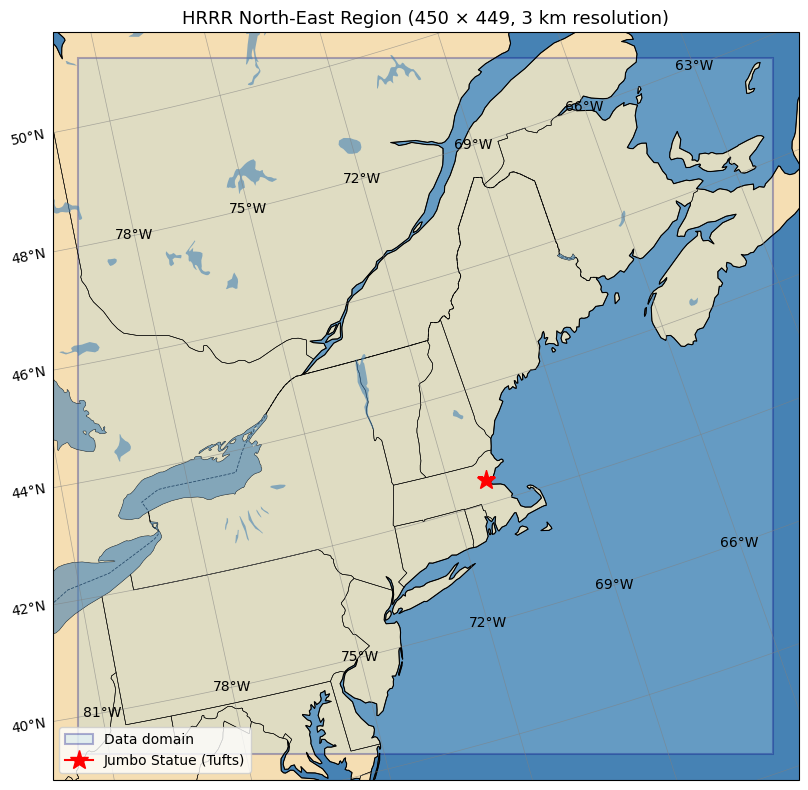

In [ ]:
fig, ax = plt.subplots(
    figsize=(10, 8),
    subplot_kw={'projection': projection}
)

# Shade the data domain
x_min, x_max = x_coords[0], x_coords[-1]
y_min, y_max = y_coords[0], y_coords[-1]
ax.add_patch(
    plt.Rectangle(
        (x_min, y_min), x_max - x_min, y_max - y_min,
        transform=projection,
        facecolor='lightblue', edgecolor='navy', linewidth=1.5,
        alpha=0.3, label='Data domain'
    )
)

# Geographic features
ax.add_feature(cfeature.LAND,       facecolor='wheat',     zorder=0)
ax.add_feature(cfeature.OCEAN,      facecolor='steelblue', zorder=0)
ax.add_feature(cfeature.COASTLINE,  linewidth=0.8)
ax.add_feature(cfeature.BORDERS,    linewidth=0.6, linestyle='--')
ax.add_feature(cfeature.STATES,     linewidth=0.4)
ax.add_feature(cfeature.LAKES,      facecolor='steelblue', alpha=0.6)

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.6)
gl.top_labels = False
gl.right_labels = False

# Mark the Jumbo Statue location
ax.plot(
    JUMBO_LON, JUMBO_LAT,
    marker='*', color='red', markersize=14,
    transform=ccrs.PlateCarree(),
    zorder=5, label='Jumbo Statue (Tufts)'
)

# Set extent to data domain (with a small margin)
margin = 50_000   # 50 km
ax.set_extent(
    [x_min - margin, x_max + margin, y_min - margin, y_max + margin],
    crs=projection
)

ax.set_title('HRRR North-East Region (450 × 449, 3 km resolution)', fontsize=13)
ax.legend(loc='lower left', fontsize=10)
plt.tight_layout()
plt.savefig(f'./fig1_region_map.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 2 – Temperature over the spatial area (one snapshot)

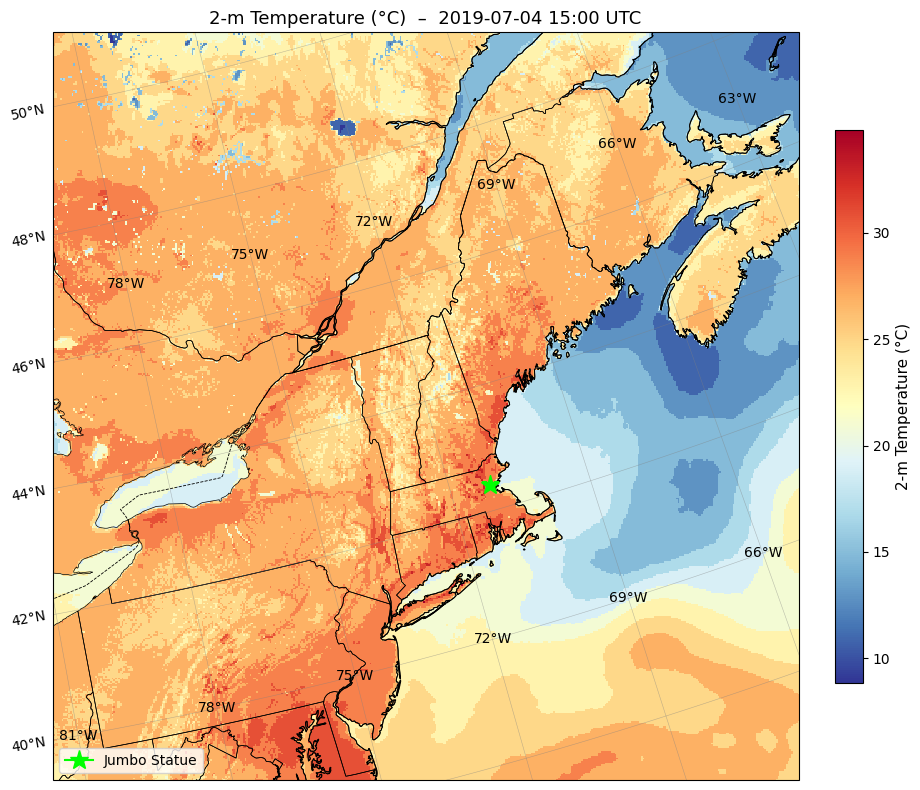

In [ ]:
# Pick a summer afternoon snapshot for a visually interesting example
EXAMPLE_TIME = '2019-07-04T15:00'

# Load the corresponding input tensor  →  X_YYYYMMDDHH.pt
dt = pd.Timestamp(EXAMPLE_TIME)
fname = f"{DATASET_DIR}/inputs/{dt.year}/X_{dt.strftime('%Y%m%d%H')}.pt"
x = torch.load(fname, weights_only=True).float()   # (450, 449, 42)

# Extract TMP channel (channel 0) and convert K → °C
tmp_c = x[:, :, TMP_CHANNEL].numpy() - 273.15      # (450, 449)

fig, ax = plt.subplots(
    figsize=(10, 8),
    subplot_kw={'projection': projection}
)

mesh = ax.pcolormesh(
    x_coords, y_coords, tmp_c,
    transform=projection,
    cmap='RdYlBu_r',
    shading='auto'
)
cbar = plt.colorbar(mesh, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('2-m Temperature (°C)', fontsize=11)

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.STATES,    linewidth=0.5, edgecolor='black')
ax.add_feature(cfeature.BORDERS,   linewidth=0.6, linestyle='--')

gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Mark the Jumbo Statue
ax.plot(
    JUMBO_LON, JUMBO_LAT,
    marker='*', color='lime', markersize=14,
    transform=ccrs.PlateCarree(),
    zorder=5, label='Jumbo Statue'
)
ax.legend(loc='lower left', fontsize=10)

ax.set_title(
    f'2-m Temperature (°C)  –  {dt.strftime("%Y-%m-%d %H:%M UTC")}',
    fontsize=13
)
ax.set_extent(
    [x_coords[0], x_coords[-1], y_coords[0], y_coords[-1]],
    crs=projection
)
plt.tight_layout()
plt.savefig(f'./fig2_temperature_spatial.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 3 – Average temperature over one year

Daily-mean 2-m temperature at the Jumbo Statue grid point for calendar year 2019.

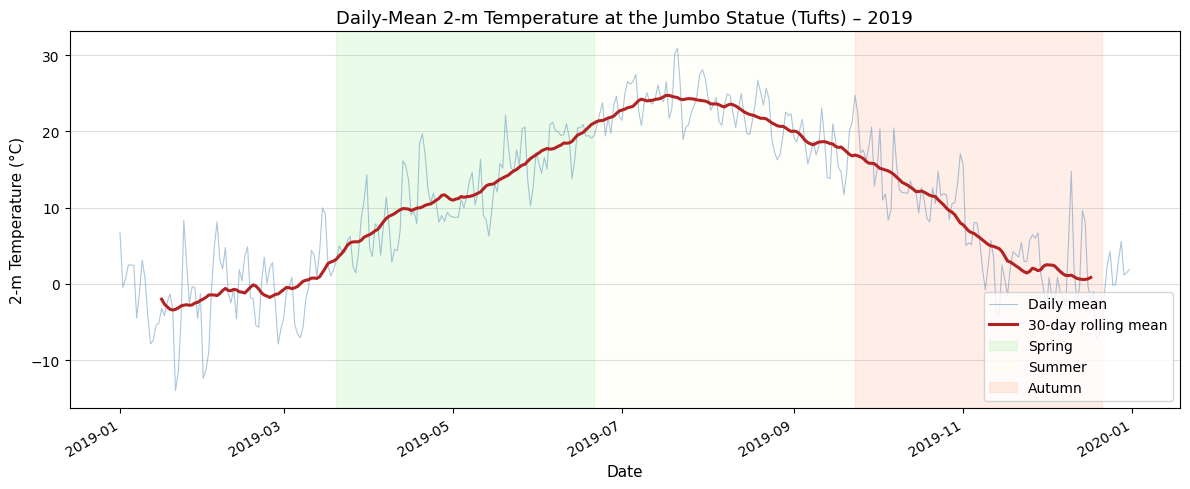

In [ ]:
# Load targets.pt — contains TMP at Jumbo for all 26 280 hourly timesteps
targets = torch.load(f'{DATASET_DIR}/targets.pt', weights_only=False)
all_times = targets['time']                        # numpy datetime64[ns], shape (T,)
tmp_all   = targets['values'][:, 0].numpy()        # TMP@2m_above_ground (K), shape (T,)

# Filter to calendar year 2019
years      = all_times.astype('datetime64[Y]').astype(int) + 1970
mask_2019  = years == 2019
times_2019 = pd.to_datetime(all_times[mask_2019])
tmp_2019   = tmp_all[mask_2019] - 273.15           # K → °C

# Daily mean via pandas resample
tmp_series = pd.Series(tmp_2019, index=times_2019)
tmp_daily  = tmp_series.resample('1D').mean()

# 30-day rolling average for a smooth seasonal cycle
tmp_smooth = tmp_daily.rolling(30, center=True).mean()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(tmp_daily.index, tmp_daily.values,
        color='steelblue', alpha=0.45, linewidth=0.8, label='Daily mean')
ax.plot(tmp_smooth.index, tmp_smooth.values,
        color='firebrick', linewidth=2.2, label='30-day rolling mean')

# Shade seasons
seasons = [
    ('2019-03-20', '2019-06-21', 'lightgreen',  'Spring'),
    ('2019-06-21', '2019-09-23', 'lightyellow', 'Summer'),
    ('2019-09-23', '2019-12-21', 'lightsalmon', 'Autumn'),
]
for start, end, color, label in seasons:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               alpha=0.18, color=color, label=label)

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('2-m Temperature (°C)', fontsize=11)
ax.set_title(
    'Daily-Mean 2-m Temperature at the Jumbo Statue (Tufts) – 2019',
    fontsize=13
)
ax.legend(fontsize=10, loc='lower right')
ax.grid(axis='y', alpha=0.4)
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(f'./fig3_temperature_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()